# Kuramoto Grid Sweep: Singular Spectrum / EC / Coarse Coeff / Frequency

这个 notebook 用于一次遍历多个参数组合：
- `n_clusters`
- `K_intra`
- `K_inter`
- `noise`

并统一比较：
1. 奇异值谱（Singular spectrum）
2. 因果涌现指标 EC
3. 粗粒化函数系数 `coarse_grain_coff`
4. 频谱分析（FFT 主频 + 宏变量相干性）


In [1]:
import os
import sys
from itertools import product
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pysindy as ps

from sklearn.linear_model import Lasso
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from scipy.fft import fft, fftfreq
from scipy.signal import coherence

sys.path.append(os.path.abspath('..'))
from tools import get_positive_contributions, compute_entropy, compute_gram_matrix_for_sindy
from data.data_func import generate_kuramoto_cluster_data_sin_cos

sns.set_theme(style="whitegrid")


In [2]:
# ===== Global experiment config (edit here) =====
N = 10
T = 25.0
DT = 0.01
BURN_IN = 1000            # drop transient samples

# Grid
N_CLUSTERS_GRID = [2, 5]
K_INTRA_GRID = [2.0, 5.0]
K_INTER_GRID = [0.05, 0.2, 0.5]
NOISE_GRID = [0.0, 0.01, 0.03]

# Modeling
DISCRETE_TIME = False
RANK = 2
N_SINGULAR_KEEP = 8
RANDOM_SEED_OMEGA = 0
BASE_SEED_THETA = 0

# SINDy / lifting
identity_lib = ps.IdentityLibrary()
fourier_lib = ps.FourierLibrary(n_frequencies=1)
library = identity_lib + fourier_lib
optimizer = Lasso(alpha=0.005, max_iter=20000, fit_intercept=False)

print("Total combos:", len(list(product(N_CLUSTERS_GRID, K_INTRA_GRID, K_INTER_GRID, NOISE_GRID))))


Total combos: 36


In [3]:
def inverse_sqrt_psd(M, eps=1e-10):
    M_sym = 0.5 * (M + M.T)
    evals, evecs = np.linalg.eigh(M_sym)
    evals_clipped = np.clip(evals, eps, None)
    M_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals_clipped)) @ evecs.T
    M_sqrt = evecs @ np.diag(np.sqrt(evals_clipped)) @ evecs.T
    return M_sqrt, M_inv_sqrt, evals


def compute_fft_features(signal, dt):
    n = len(signal)
    freq = fftfreq(n, dt)
    yf = fft(signal)
    half = n // 2
    f = freq[:half]
    amp = np.abs(yf[:half]) * 2.0 / n
    if len(amp) > 1:
        idx = np.argmax(amp[1:]) + 1
    else:
        idx = 0
    dom_freq = float(f[idx]) if len(f) else np.nan
    dom_amp = float(amp[idx]) if len(amp) else np.nan
    return f, amp, dom_freq, dom_amp


def top_features_from_coarse(coarse_grain_coff, names, top_k=3):
    tops = {}
    for j in range(coarse_grain_coff.shape[1]):
        col = np.abs(coarse_grain_coff[:, j])
        idx = np.argsort(col)[::-1][:top_k]
        tops[f"y{j}"] = [(names[i], float(col[i])) for i in idx]
    return tops


def run_single_experiment(n_clusters, K_intra, K_inter, noise, seed_theta, rank=2):
    # 1) Generate Kuramoto data
    X_embed, theta_hist, t, K_matrix = generate_kuramoto_cluster_data_sin_cos(
        N=N,
        n_clusters=n_clusters,
        K_intra=K_intra,
        K_inter=K_inter,
        dt=DT,
        T=T,
        noise=noise,
        random_seed1=RANDOM_SEED_OMEGA,
        random_seed2=seed_theta,
    )

    x_data = X_embed[BURN_IN:, :]

    # 2) Lift
    library.fit(x_data)
    x_data_lift = library.transform(x_data)
    names = library.get_feature_names()

    # 3) Gram
    G = compute_gram_matrix_for_sindy(library, [x_data], weights="uniform")

    # 4) Fit SINDy in lifted space
    model = ps.SINDy(
        feature_library=identity_lib,
        optimizer=optimizer,
        discrete_time=DISCRETE_TIME,
    )
    model.fit(x_data_lift, t=DT, feature_names=names)

    # 5) Build whitened Koopman operator A
    A_raw = model.coefficients()
    xdot_model = model.predict(x_data_lift)
    denom = np.linalg.norm(xdot_model) + 1e-12
    err_no_t = np.linalg.norm(xdot_model - x_data_lift @ A_raw.T) / denom
    err_t = np.linalg.norm(xdot_model - x_data_lift @ A_raw) / denom
    A_ct = A_raw if err_t <= err_no_t else A_raw.T
    A_step = scipy.linalg.expm(A_ct * DT) if not DISCRETE_TIME else A_ct

    G_sqrt, G_inv_sqrt, G_eigs = inverse_sqrt_psd(G, eps=1e-10)
    A = G_sqrt @ A_step @ G_inv_sqrt

    # 6) SVD / EC
    U, S, Vh = np.linalg.svd(A)
    diff = get_positive_contributions(S)
    ec = float(compute_entropy(diff))

    # 7) Coarse-grain coeff
    rank_eff = min(rank, U.shape[1])
    coarse_grain_coff = G_inv_sqrt @ U[:, :rank_eff]
    coarse_abs_mean = float(np.mean(np.abs(coarse_grain_coff)))
    coarse_abs_max = float(np.max(np.abs(coarse_grain_coff)))

    # 8) Frequency on macro vars
    macro_data = x_data_lift @ coarse_grain_coff

    macro_signals = []
    dom_freqs = []
    dom_amps = []
    spectrum_dict = {}
    for i in range(rank_eff):
        sig = macro_data[:, i]
        sig_std = (sig - np.mean(sig)) / (np.std(sig) + 1e-12)
        macro_signals.append(sig_std)
        f, amp, f0, a0 = compute_fft_features(sig_std, DT)
        dom_freqs.append(f0)
        dom_amps.append(a0)
        spectrum_dict[f"y{i}"] = {"f": f, "amp": amp}

    coherence_peak = np.nan
    if rank_eff >= 2:
        nseg = min(256, max(32, len(macro_signals[0]) // 4))
        f_coh, cxy = coherence(macro_signals[0], macro_signals[1], fs=1.0 / DT, nperseg=nseg)
        coherence_peak = float(np.max(cxy))

    singular_head = S[:N_SINGULAR_KEEP]

    summary = {
        "n_clusters": n_clusters,
        "K_intra": K_intra,
        "K_inter": K_inter,
        "noise": noise,
        "seed_theta": seed_theta,
        "ec": ec,
        "coarse_abs_mean": coarse_abs_mean,
        "coarse_abs_max": coarse_abs_max,
        "dom_freq_mean": float(np.nanmean(dom_freqs)) if len(dom_freqs) else np.nan,
        "dom_amp_mean": float(np.nanmean(dom_amps)) if len(dom_amps) else np.nan,
        "coherence_peak": coherence_peak,
        "orientation_err_A": float(err_t),
        "orientation_err_AT": float(err_no_t),
    }
    for i in range(N_SINGULAR_KEEP):
        summary[f"sv_{i+1}"] = float(singular_head[i]) if i < len(singular_head) else np.nan

    artifacts = {
        "A": A,
        "S": S,
        "U": U,
        "coarse_grain_coff": coarse_grain_coff,
        "names": names,
        "macro_data": macro_data,
        "spectrum": spectrum_dict,
        "top_features": top_features_from_coarse(coarse_grain_coff, names, top_k=5),
    }

    return summary, artifacts


In [4]:
# ===== Sweep all combinations =====
rows = []
artifacts_store = {}

grid = list(product(N_CLUSTERS_GRID, K_INTRA_GRID, K_INTER_GRID, NOISE_GRID))
for idx, (n_clusters, K_intra, K_inter, noise) in enumerate(grid, start=1):
    seed_theta = BASE_SEED_THETA + idx
    print(f"[{idx:02d}/{len(grid)}] n_clusters={n_clusters}, K_intra={K_intra}, K_inter={K_inter}, noise={noise}")
    summary, artifacts = run_single_experiment(
        n_clusters=n_clusters,
        K_intra=K_intra,
        K_inter=K_inter,
        noise=noise,
        seed_theta=seed_theta,
        rank=RANK,
    )
    key = (n_clusters, K_intra, K_inter, noise)
    rows.append(summary)
    artifacts_store[key] = artifacts

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(["n_clusters", "noise", "K_intra", "K_inter"]).reset_index(drop=True)

print("\nSweep done. Rows:", len(results_df))
results_df.head()


[01/36] n_clusters=2, K_intra=2.0, K_inter=0.05, noise=0.0
检测到 1 条轨迹
各轨迹时间步数: [1500]
总样本数 M = 1500
观测函数个数 N = 60
使用均匀权重（所有样本等权重）
Gram 矩阵形状: (60, 60)
[02/36] n_clusters=2, K_intra=2.0, K_inter=0.05, noise=0.01
检测到 1 条轨迹
各轨迹时间步数: [1500]
总样本数 M = 1500
观测函数个数 N = 60
使用均匀权重（所有样本等权重）
Gram 矩阵形状: (60, 60)
[03/36] n_clusters=2, K_intra=2.0, K_inter=0.05, noise=0.03
检测到 1 条轨迹
各轨迹时间步数: [1500]
总样本数 M = 1500
观测函数个数 N = 60
使用均匀权重（所有样本等权重）
Gram 矩阵形状: (60, 60)
[04/36] n_clusters=2, K_intra=2.0, K_inter=0.2, noise=0.0
检测到 1 条轨迹
各轨迹时间步数: [1500]
总样本数 M = 1500
观测函数个数 N = 60
使用均匀权重（所有样本等权重）
Gram 矩阵形状: (60, 60)
[05/36] n_clusters=2, K_intra=2.0, K_inter=0.2, noise=0.01
检测到 1 条轨迹
各轨迹时间步数: [1500]
总样本数 M = 1500
观测函数个数 N = 60
使用均匀权重（所有样本等权重）
Gram 矩阵形状: (60, 60)
[06/36] n_clusters=2, K_intra=2.0, K_inter=0.2, noise=0.03
检测到 1 条轨迹
各轨迹时间步数: [1500]
总样本数 M = 1500
观测函数个数 N = 60
使用均匀权重（所有样本等权重）
Gram 矩阵形状: (60, 60)
[07/36] n_clusters=2, K_intra=2.0, K_inter=0.5, noise=0.0
检测到 1 条轨迹
各轨迹时间步数: [1500]
总样本数 M = 1500
观测函数个数 

,n_clusters,K_intra,K_inter,noise,seed_theta,ec,coarse_abs_mean,coarse_abs_max,dom_freq_mean,dom_amp_mean,...,orientation_err_A,orientation_err_AT,sv_1,sv_2,sv_3,sv_4,sv_5,sv_6,sv_7,sv_8
0,2,2.0,0.05,0.0,1,4.962933,2689.808879,20659.826057,0.800000,1.140362,...,3.335331,0.0,2.995494,2.126062,1.902745,1.715997,1.707446,1.609797,1.258602,1.229086
1,2,2.0,0.20,0.0,4,5.124224,1877.743559,16007.155263,0.233333,1.000345,...,3.305297,0.0,4.318346,2.972547,2.405400,2.120643,1.952080,1.938678,1.797710,1.629511
2,2,2.0,0.50,0.0,7,5.423726,603.347014,3203.700543,0.600000,0.940018,...,2.479850,0.0,15.328609,14.239567,12.775774,6.799331,5.499999,4.458770,3.709154,3.570201
3,2,5.0,0.05,0.0,10,4.488601,2161.155919,21346.033161,0.400000,1.188717,...,5.821425,0.0,4.030493,2.259325,2.142145,1.553086,1.427539,1.383826,1.065147,1.058185
4,2,5.0,0.20,0.0,13,5.038312,1955.495045,16707.121464,0.400000,1.204201,...,5.861047,0.0,3.405895,3.009015,2.285349,2.138868,1.922400,1.371270,1.214653,1.182027


In [5]:
# ===== Summary table =====
metric_cols = [
    "n_clusters", "K_intra", "K_inter", "noise",
    "ec", "coarse_abs_mean", "coarse_abs_max",
    "dom_freq_mean", "dom_amp_mean", "coherence_peak"
] + [f"sv_{i+1}" for i in range(min(5, N_SINGULAR_KEEP))]

display(results_df[metric_cols].sort_values("ec", ascending=False).head(20))


,n_clusters,K_intra,K_inter,noise,ec,coarse_abs_mean,coarse_abs_max,dom_freq_mean,dom_amp_mean,coherence_peak,sv_1,sv_2,sv_3,sv_4,sv_5
13,2,2.0,0.20,0.03,5.693504,28.841152,142.559464,0.233333,0.470194,0.544083,1.046754,1.043796,1.041763,1.036012,1.031917
18,5,2.0,0.05,0.00,5.693208,186.957447,1509.054430,0.400000,1.031455,0.209853,43.880581,38.738464,24.489410,22.318179,16.884838
14,2,2.0,0.50,0.03,5.690439,27.085091,123.367207,0.500000,0.493360,0.491979,1.044821,1.041795,1.036634,1.032339,1.028509
29,5,5.0,0.50,0.01,5.683463,69.437839,385.913647,0.533333,0.492614,0.483226,1.073929,1.070491,1.059717,1.057909,1.051088
30,5,2.0,0.05,0.03,5.669490,28.095997,107.187611,0.600000,0.496689,0.429671,1.045779,1.040342,1.038523,1.033289,1.031289
10,2,5.0,0.20,0.01,5.646610,65.482118,214.203376,0.500000,0.607321,0.560398,1.075126,1.070392,1.066822,1.057780,1.049052
11,2,5.0,0.50,0.01,5.643114,77.927552,458.590819,0.800000,0.731018,0.461124,1.086335,1.081031,1.076900,1.074152,1.065652
16,2,5.0,0.20,0.03,5.619857,25.603322,93.799850,0.466667,0.471139,0.316008,1.043064,1.035754,1.031329,1.030434,1.029546
34,5,5.0,0.20,0.03,5.599133,23.269528,157.066410,0.500000,0.560479,0.593925,1.049375,1.041070,1.039192,1.036254,1.029380
28,5,5.0,0.20,0.01,5.589794,70.614071,307.607531,0.566667,0.604238,0.562820,1.092419,1.085928,1.073568,1.065675,1.056981


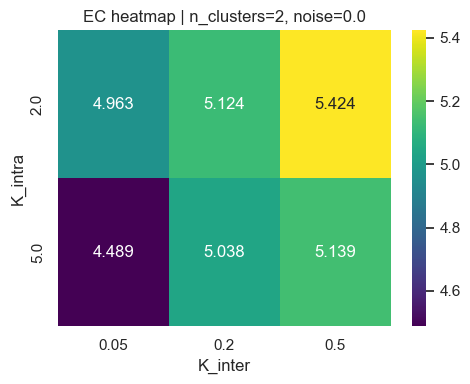

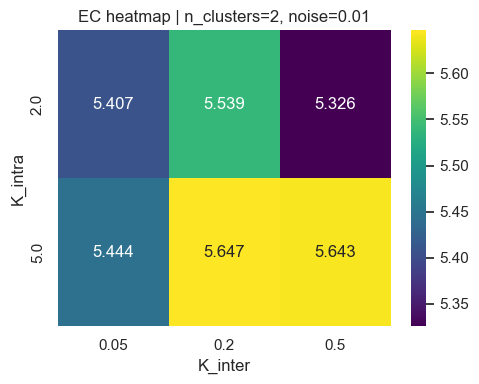

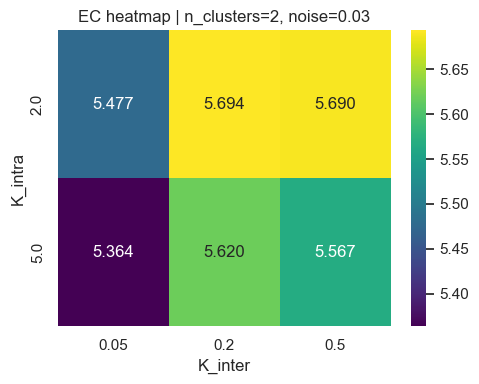

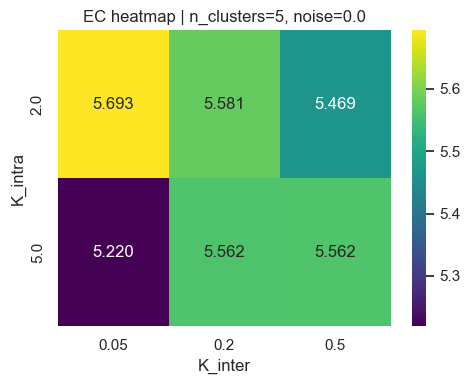

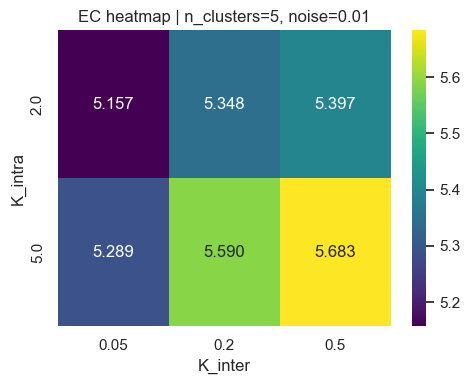

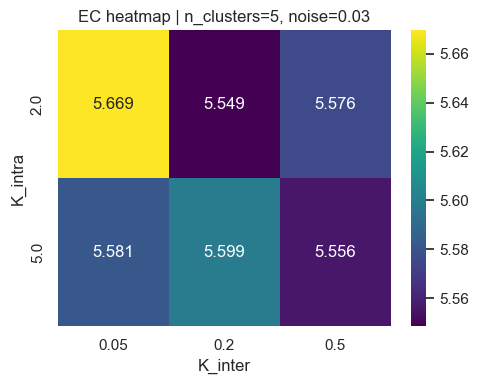

In [6]:
# ===== EC heatmaps by (n_clusters, noise) =====
for n_clusters in sorted(results_df["n_clusters"].unique()):
    for noise in sorted(results_df["noise"].unique()):
        sub = results_df[(results_df["n_clusters"] == n_clusters) & (results_df["noise"] == noise)]
        if sub.empty:
            continue
        piv = sub.pivot(index="K_intra", columns="K_inter", values="ec")
        plt.figure(figsize=(5, 4))
        sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis")
        plt.title(f"EC heatmap | n_clusters={n_clusters}, noise={noise}")
        plt.ylabel("K_intra")
        plt.xlabel("K_inter")
        plt.tight_layout()
        plt.show()


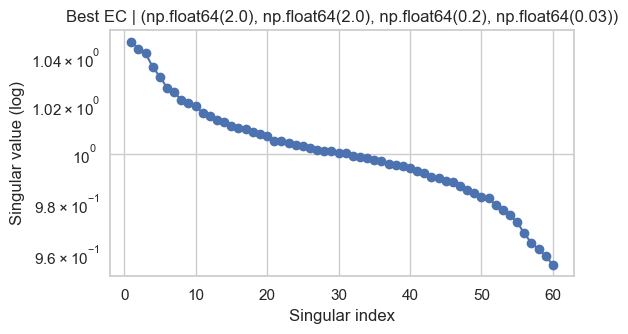

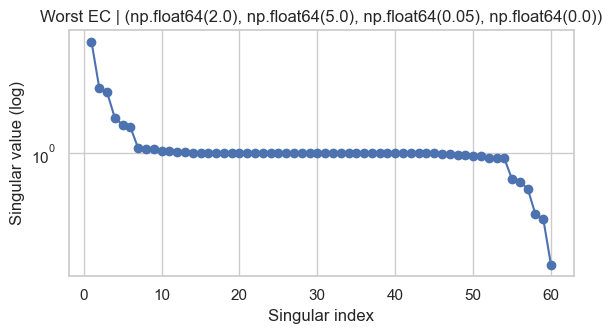

Best EC row:


n_clusters    2.000000
K_intra       2.000000
K_inter       0.200000
noise         0.030000
ec            5.693504
sv_1          1.046754
sv_2          1.043796
sv_3          1.041763
sv_4          1.036012
sv_5          1.031917
Name: 13, dtype: float64

Worst EC row:


n_clusters    2.000000
K_intra       5.000000
K_inter       0.050000
noise         0.000000
ec            4.488601
sv_1          4.030493
sv_2          2.259325
sv_3          2.142145
sv_4          1.553086
sv_5          1.427539
Name: 3, dtype: float64

In [7]:
# ===== Singular spectrum comparison for top-EC and low-EC cases =====
best_idx = results_df["ec"].idxmax()
worst_idx = results_df["ec"].idxmin()

best_row = results_df.loc[best_idx]
worst_row = results_df.loc[worst_idx]

best_key = (best_row.n_clusters, best_row.K_intra, best_row.K_inter, best_row.noise)
worst_key = (worst_row.n_clusters, worst_row.K_intra, worst_row.K_inter, worst_row.noise)

for key, label in [(best_key, "Best EC"), (worst_key, "Worst EC")]:
    S = artifacts_store[key]["S"]
    plt.figure(figsize=(6, 3.5))
    plt.plot(np.arange(1, len(S) + 1), S, marker="o")
    plt.yscale("log")
    plt.xlabel("Singular index")
    plt.ylabel("Singular value (log)")
    plt.title(f"{label} | {key}")
    plt.tight_layout()
    plt.show()

print("Best EC row:")
display(best_row[["n_clusters", "K_intra", "K_inter", "noise", "ec"] + [f"sv_{i+1}" for i in range(min(5, N_SINGULAR_KEEP))]])
print("Worst EC row:")
display(worst_row[["n_clusters", "K_intra", "K_inter", "noise", "ec"] + [f"sv_{i+1}" for i in range(min(5, N_SINGULAR_KEEP))]])


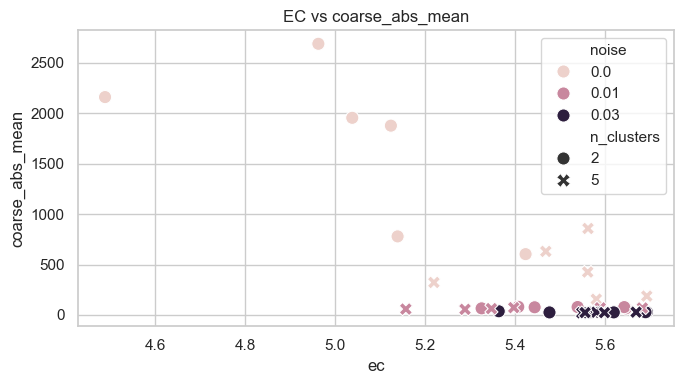

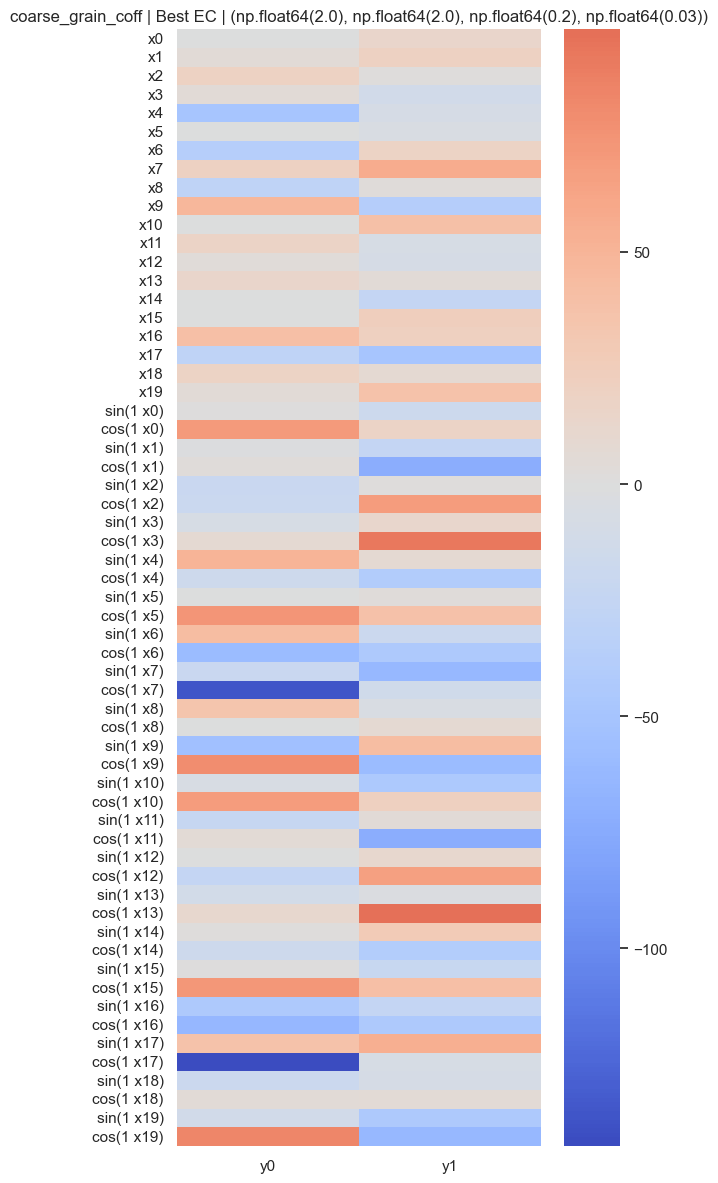

Top contributing lifted features | Best EC | (np.float64(2.0), np.float64(2.0), np.float64(0.2), np.float64(0.03))
y0 -> [('cos(1 x17)', 142.55946424361494), ('cos(1 x7)', 136.03915250174407), ('cos(1 x19)', 83.34330447260449), ('cos(1 x9)', 78.46072365977702), ('cos(1 x5)', 73.8310358585484)]
y1 -> [('cos(1 x13)', 97.94009091227008), ('cos(1 x3)', 93.19430487745844), ('cos(1 x11)', 72.89094123911683), ('cos(1 x1)', 72.70639181784261), ('cos(1 x2)', 68.93476790924359)]
--------------------------------------------------------------------------------


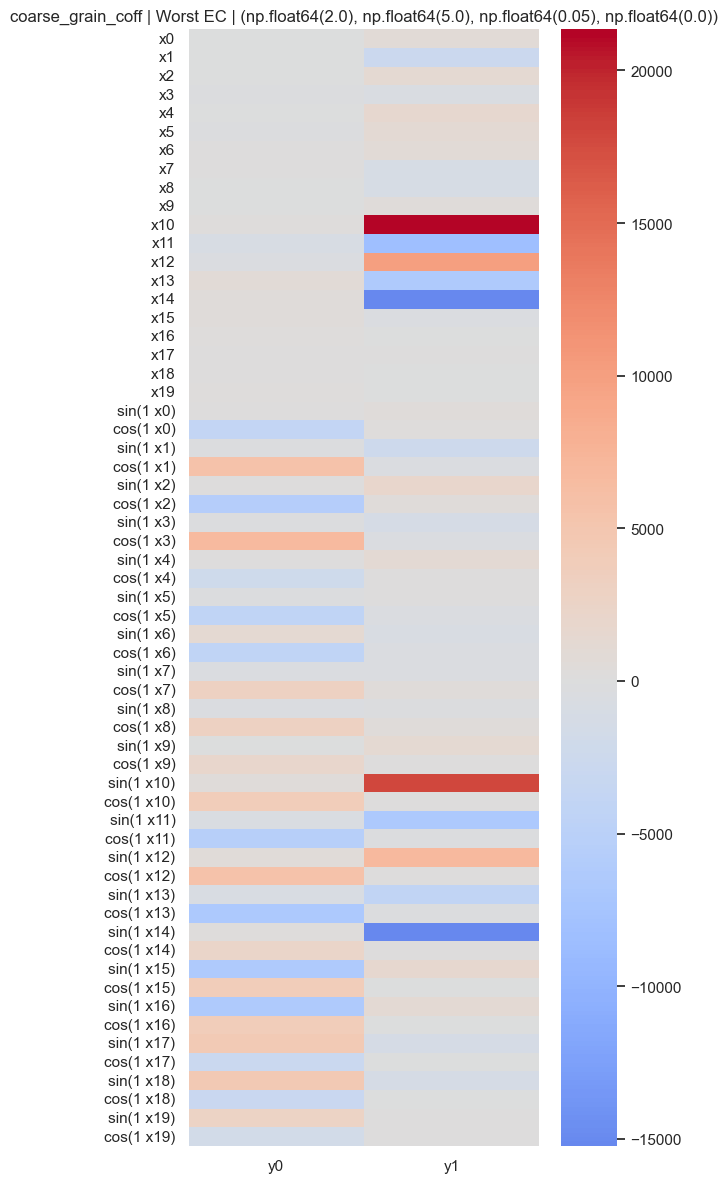

Top contributing lifted features | Worst EC | (np.float64(2.0), np.float64(5.0), np.float64(0.05), np.float64(0.0))
y0 -> [('cos(1 x13)', 6681.805454759595), ('cos(1 x3)', 6647.948850684804), ('sin(1 x16)', 6509.197339370938), ('sin(1 x15)', 6490.829973741113), ('cos(1 x2)', 5705.92231839538)]
y1 -> [('x10', 21346.033160968993), ('sin(1 x10)', 17778.86769312032), ('x14', 15231.96925240329), ('sin(1 x14)', 15119.393547199412), ('x12', 10054.720145799201)]
--------------------------------------------------------------------------------


In [8]:
# ===== Coarse-grain coefficient analysis =====
# 1) Global trend
plt.figure(figsize=(7, 4))
sns.scatterplot(data=results_df, x="ec", y="coarse_abs_mean", hue="noise", style="n_clusters", s=90)
plt.title("EC vs coarse_abs_mean")
plt.tight_layout()
plt.show()

# 2) Visualize coarse_grain_coff for best/worst EC
for key, label in [(best_key, "Best EC"), (worst_key, "Worst EC")]:
    coeff = artifacts_store[key]["coarse_grain_coff"]
    names = artifacts_store[key]["names"]
    plt.figure(figsize=(6, max(4, coeff.shape[0] * 0.2)))
    sns.heatmap(coeff, cmap="coolwarm", center=0, yticklabels=names, xticklabels=[f"y{i}" for i in range(coeff.shape[1])])
    plt.title(f"coarse_grain_coff | {label} | {key}")
    plt.tight_layout()
    plt.show()

    print(f"Top contributing lifted features | {label} | {key}")
    for macro_var, top_items in artifacts_store[key]["top_features"].items():
        print(macro_var, "->", top_items[:5])
    print("-" * 80)


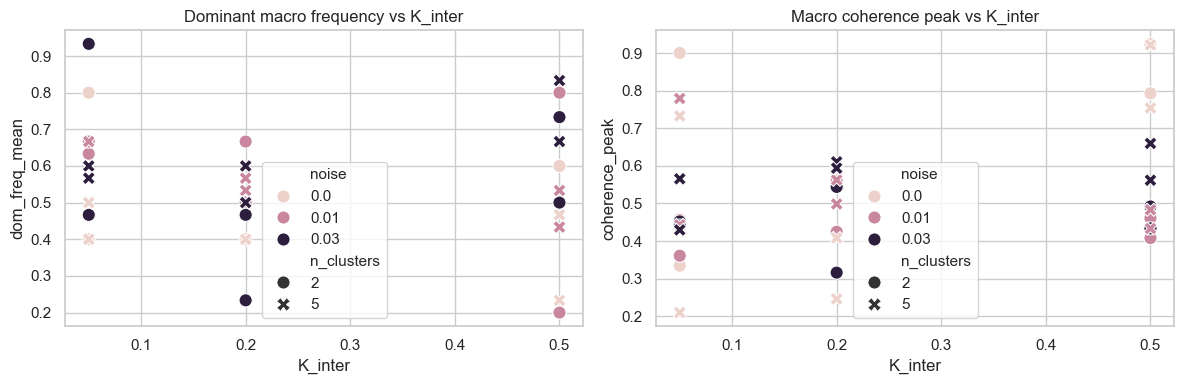

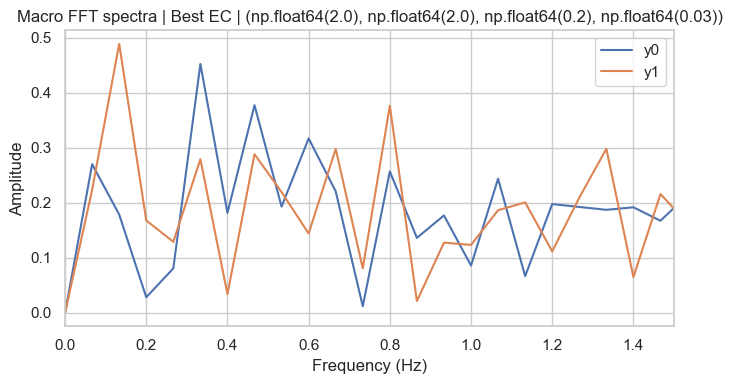

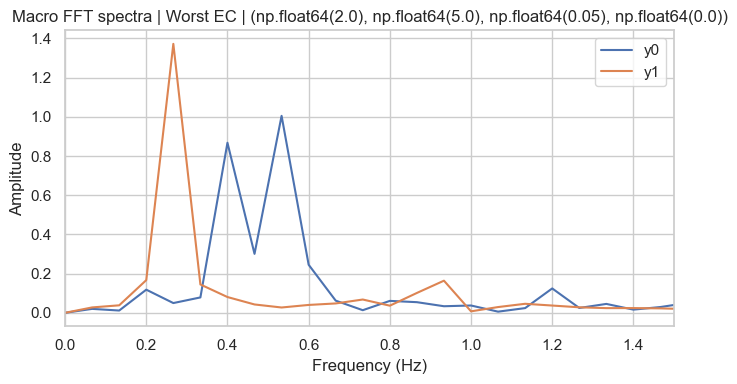

In [9]:
# ===== Frequency analysis comparison =====
# 1) Aggregate metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=results_df, x="K_inter", y="dom_freq_mean", hue="noise", style="n_clusters", s=90, ax=axes[0])
axes[0].set_title("Dominant macro frequency vs K_inter")

sns.scatterplot(data=results_df, x="K_inter", y="coherence_peak", hue="noise", style="n_clusters", s=90, ax=axes[1])
axes[1].set_title("Macro coherence peak vs K_inter")
plt.tight_layout()
plt.show()

# 2) Detailed spectra for best/worst EC
for key, label in [(best_key, "Best EC"), (worst_key, "Worst EC")]:
    spec = artifacts_store[key]["spectrum"]
    plt.figure(figsize=(7, 4))
    for macro_var, dat in spec.items():
        f = dat["f"]
        amp = dat["amp"]
        plt.plot(f, amp, label=macro_var)
    plt.xlim(0, 1.5)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title(f"Macro FFT spectra | {label} | {key}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Notes

- 如果想要更稳定统计，可把每个参数组合重复多次（不同 `seed_theta`）并做均值/方差。
- 若组合较多导致计算慢，可先缩小参数网格再扩展。
- 当前 `RANK=2`，可调整并对比不同 rank 对 EC/频谱/粗粒化表达的影响。
